In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

PNG_DIR = Path(
    "/content/drive/MyDrive/気合のCOVID19/"
    "01_TaskA_CXR/01_前処理/processed_png_1277"
)

SPLIT_PATH = Path(
    "/content/drive/MyDrive/気合のCOVID19/"
    "00_共通・研究管理/03_患者選定/"
    "COVID19_固定患者split_1277.csv"
)

split_df = pd.read_csv(SPLIT_PATH)

print("split件数:", len(split_df))
print("列名:")
print(split_df.columns.tolist())

print("\n先頭5行:")
display(split_df.head())

print("\nsplit内訳:")
print(split_df["split"].value_counts() if "split" in split_df.columns else "split列名を確認してください")

Mounted at /content/drive
split件数: 1277
列名:
['Subject ID', 'to_patient_id', 'last.status', 'true_label', 'split']

先頭5行:


,Subject ID,to_patient_id,last.status,true_label,split
0,A934023,A934023,discharged,0,train
1,A333626,A333626,discharged,0,train
2,A363365,A363365,discharged,0,train
3,A303446,A303446,discharged,0,train
4,A463459,A463459,discharged,0,train



split内訳:
split
train    1021
val       128
test      128
Name: count, dtype: int64


In [4]:
# PNGと固定splitの患者ID対応を監査

png_files = sorted(PNG_DIR.glob("*.png"))
png_ids = {p.stem for p in png_files}

split_ids = set(split_df["Subject ID"].astype(str))

print("=== 件数 ===")
print("PNG:", len(png_files))
print("PNG患者IDユニーク:", len(png_ids))
print("split患者数:", len(split_df))
print("split患者IDユニーク:", split_df["Subject ID"].nunique())

print("\n=== ID照合 ===")
print("splitにあるがPNGにない:", len(split_ids - png_ids))
print("PNGにあるがsplitにない:", len(png_ids - split_ids))

if split_ids - png_ids:
    print("\nsplitのみのID:")
    print(sorted(split_ids - png_ids)[:20])

if png_ids - split_ids:
    print("\nPNGのみのID:")
    print(sorted(png_ids - split_ids)[:20])

print("\n=== split別ラベル内訳 ===")
print(
    pd.crosstab(
        split_df["split"],
        split_df["true_label"],
        margins=True
    )
)

=== 件数 ===
PNG: 1277
PNG患者IDユニーク: 1277
split患者数: 1277
split患者IDユニーク: 1277

=== ID照合 ===
splitにあるがPNGにない: 0
PNGにあるがsplitにない: 0

=== split別ラベル内訳 ===
true_label     0    1   All
split                      
test         111   17   128
train        886  135  1021
val          111   17   128
All         1108  169  1277


In [5]:
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
import torch

# ImageNet normalization
base_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class CXRDataset(Dataset):
    def __init__(self, dataframe, png_dir, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.png_dir = png_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        patient_id = str(row["Subject ID"])
        label = int(row["true_label"])

        img_path = self.png_dir / f"{patient_id}.png"

        image = Image.open(img_path).convert("L")

        if self.transform is not None:
            image = self.transform(image)

        return {
            "image": image,
            "label": torch.tensor(label, dtype=torch.float32),
            "patient_id": patient_id
        }


# split別DataFrame
train_df = split_df[split_df["split"] == "train"].copy()
val_df   = split_df[split_df["split"] == "val"].copy()
test_df  = split_df[split_df["split"] == "test"].copy()

# まずはaugmentationなし
train_dataset = CXRDataset(train_df, PNG_DIR, transform=base_transform)
val_dataset   = CXRDataset(val_df, PNG_DIR, transform=base_transform)
test_dataset  = CXRDataset(test_df, PNG_DIR, transform=base_transform)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

sample = train_dataset[0]

print("\n=== 1症例確認 ===")
print("Patient ID:", sample["patient_id"])
print("Label:", sample["label"])
print("Image shape:", sample["image"].shape)
print("dtype:", sample["image"].dtype)
print("min:", sample["image"].min().item())
print("max:", sample["image"].max().item())

Train: 1021
Val: 128
Test: 128

=== 1症例確認 ===
Patient ID: A934023
Label: tensor(0.)
Image shape: torch.Size([3, 224, 224])
dtype: torch.float32
min: -2.1179039478302
max: 2.6225709915161133


In [6]:
from torchvision import transforms

# Validation / Test は常にaugmentationなし
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 条件A：旧設定ベース
train_transform_A = transforms.Compose([
    transforms.RandomAffine(
        degrees=0,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02)
    ),
    transforms.ColorJitter(
        brightness=0.05,
        contrast=0.05
    ),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 条件B：旧設定 + 軽いrotation
train_transform_B = transforms.Compose([
    transforms.RandomAffine(
        degrees=5,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02)
    ),
    transforms.ColorJitter(
        brightness=0.05,
        contrast=0.05
    ),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Patient ID: A934023


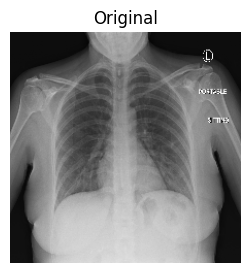

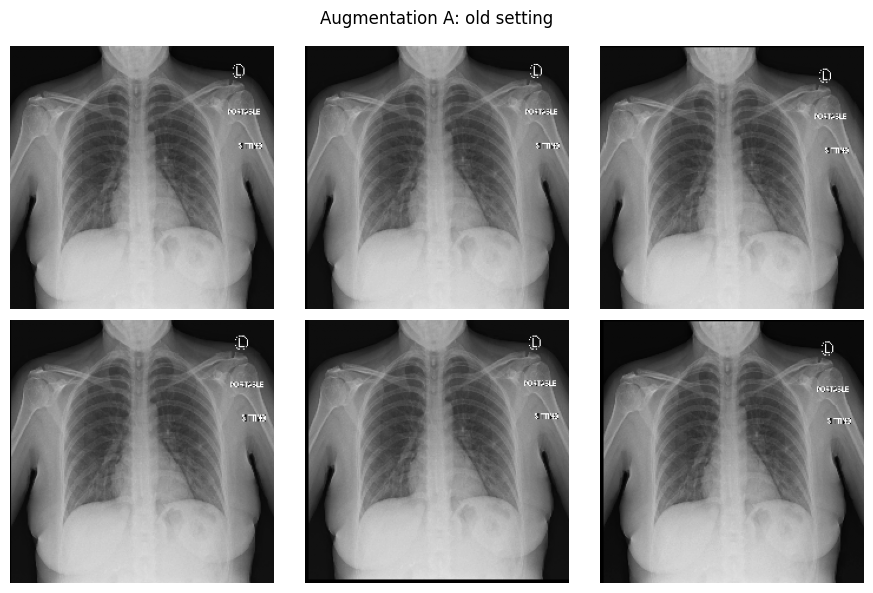

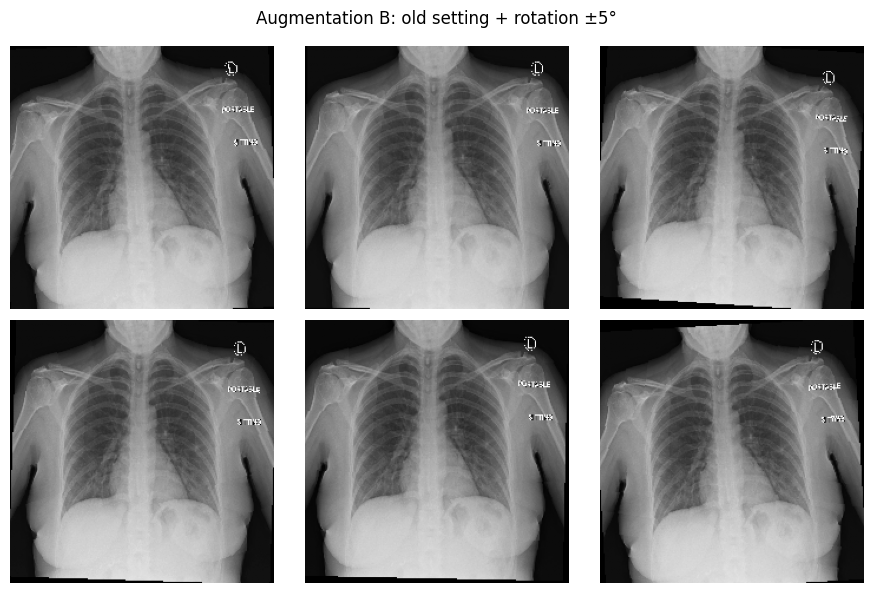

In [7]:
import matplotlib.pyplot as plt

# Trainから1症例
sample_row = train_df.iloc[0]
patient_id = str(sample_row["Subject ID"])
img_path = PNG_DIR / f"{patient_id}.png"

original = Image.open(img_path).convert("L")

# 表示用：ImageNet normalizationは外して、
# augmentation後の見た目だけ確認するtransformを作る
visual_A = transforms.Compose([
    transforms.RandomAffine(
        degrees=0,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02)
    ),
    transforms.ColorJitter(
        brightness=0.05,
        contrast=0.05
    )
])

visual_B = transforms.Compose([
    transforms.RandomAffine(
        degrees=5,
        translate=(0.02, 0.02),
        scale=(0.98, 1.02)
    ),
    transforms.ColorJitter(
        brightness=0.05,
        contrast=0.05
    )
])

print("Patient ID:", patient_id)

# Original
plt.figure(figsize=(3, 3))
plt.imshow(original, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.show()

# 条件Aを6回
fig, axes = plt.subplots(2, 3, figsize=(9, 6))

for ax in axes.flat:
    aug = visual_A(original)
    ax.imshow(aug, cmap="gray")
    ax.axis("off")

fig.suptitle("Augmentation A: old setting")
plt.tight_layout()
plt.show()

# 条件Bを6回
fig, axes = plt.subplots(2, 3, figsize=(9, 6))

for ax in axes.flat:
    aug = visual_B(original)
    ax.imshow(aug, cmap="gray")
    ax.axis("off")

fig.suptitle("Augmentation B: old setting + rotation ±5°")
plt.tight_layout()
plt.show()

In [8]:
from torch.utils.data import DataLoader

# Dataset作成
train_dataset_A = CXRDataset(
    train_df,
    PNG_DIR,
    transform=train_transform_A
)

val_dataset = CXRDataset(
    val_df,
    PNG_DIR,
    transform=eval_transform
)

test_dataset = CXRDataset(
    test_df,
    PNG_DIR,
    transform=eval_transform
)

# DataLoader
train_loader_A = DataLoader(
    train_dataset_A,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# 1 batchだけ確認
batch = next(iter(train_loader_A))

print("=== Train 1 batch確認 ===")
print("image shape:", batch["image"].shape)
print("label shape:", batch["label"].shape)
print("patient数:", len(batch["patient_id"]))

print("\nlabel:")
print(batch["label"])

print("\n先頭5患者:")
print(batch["patient_id"][:5])

=== Train 1 batch確認 ===
image shape: torch.Size([32, 3, 224, 224])
label shape: torch.Size([32])
patient数: 32

label:
tensor([0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
        1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

先頭5患者:
['A824751', 'A355016', 'A103671', 'A702224', 'A724464']


In [9]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

True
Tesla T4


In [10]:
train_dataset_B = CXRDataset(
    train_df,
    PNG_DIR,
    transform=train_transform_B
)

train_loader_B = DataLoader(
    train_dataset_B,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

batch_B = next(iter(train_loader_B))

print("=== 条件B 1 batch確認 ===")
print("image shape:", batch_B["image"].shape)
print("label shape:", batch_B["label"].shape)
print("patient数:", len(batch_B["patient_id"]))

=== 条件B 1 batch確認 ===
image shape: torch.Size([32, 3, 224, 224])
label shape: torch.Size([32])
patient数: 32


In [11]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ImageNet pretrained ResNet18
weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)

# 最終全結合層を2値分類用に変更
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, 1)

# Full fine-tuning
for param in model.parameters():
    param.requires_grad = True

model = model.to(device)

print("device:", device)
print("fc:", model.fc)

trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

total_params = sum(
    p.numel() for p in model.parameters()
)

print("trainable parameters:", trainable_params)
print("total parameters:", total_params)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 194MB/s]


device: cuda
fc: Linear(in_features=512, out_features=1, bias=True)
trainable parameters: 11177025
total parameters: 11177025


In [12]:
import copy
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images).squeeze(1)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits)

        running_loss += loss.item() * images.size(0)
        all_labels.extend(labels.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_auc = roc_auc_score(all_labels, all_probs)
    epoch_prauc = average_precision_score(all_labels, all_probs)

    return epoch_loss, epoch_auc, epoch_prauc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    for batch in loader:
        images = batch["image"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        logits = model(images).squeeze(1)
        loss = criterion(logits, labels)

        probs = torch.sigmoid(logits)

        running_loss += loss.item() * images.size(0)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_auc = roc_auc_score(all_labels, all_probs)
    epoch_prauc = average_precision_score(all_labels, all_probs)

    return epoch_loss, epoch_auc, epoch_prauc

In [13]:
import torch.optim as optim

# 試運転用モデルを作り直す
weights = models.ResNet18_Weights.IMAGENET1K_V1
model_test = models.resnet18(weights=weights)

in_features = model_test.fc.in_features
model_test.fc = nn.Linear(in_features, 1)

for param in model_test.parameters():
    param.requires_grad = True

model_test = model_test.to(device)

# 第1段階なので class weight なし
criterion = nn.BCEWithLogitsLoss()

# 条件A × LR=1e-5
optimizer = optim.AdamW(
    model_test.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

print("=== 1 epoch 試運転開始 ===")

train_loss, train_auc, train_prauc = train_one_epoch(
    model_test,
    train_loader_A,
    criterion,
    optimizer,
    device
)

val_loss, val_auc, val_prauc = evaluate(
    model_test,
    val_loader,
    criterion,
    device
)

print("\n=== 1 epoch 結果 ===")
print(f"Train Loss   : {train_loss:.4f}")
print(f"Train ROC-AUC: {train_auc:.4f}")
print(f"Train PR-AUC : {train_prauc:.4f}")
print()
print(f"Val Loss     : {val_loss:.4f}")
print(f"Val ROC-AUC  : {val_auc:.4f}")
print(f"Val PR-AUC   : {val_prauc:.4f}")

=== 1 epoch 試運転開始 ===

=== 1 epoch 結果 ===
Train Loss   : 0.6179
Train ROC-AUC: 0.7032
Train PR-AUC : 0.2916

Val Loss     : 0.4400
Val ROC-AUC  : 0.7493
Val PR-AUC   : 0.3115


In [14]:
import os
import copy
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models

def train_model_condition(
    train_loader,
    val_loader,
    lr,
    condition_name,
    device,
    output_dir,
    max_epochs=30,
    weight_decay=1e-4,
    early_stopping_patience=8,
    min_delta=0.001,
):
    """
    1条件分のResNet18学習を実行する関数

    - ImageNet pretrained ResNet18
    - Full fine-tuning
    - BCEWithLogitsLoss（class weightなし）
    - AdamW
    - ReduceLROnPlateau
    - Early stopping: Validation ROC-AUC
    - Best checkpoint: Validation ROC-AUC最大
      同値の場合はValidation lossが低い方
    """

    os.makedirs(output_dir, exist_ok=True)

    # -------------------------
    # 1. モデル作成
    # -------------------------
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 1)

    for param in model.parameters():
        param.requires_grad = True

    model = model.to(device)

    # -------------------------
    # 2. Loss / Optimizer
    # -------------------------
    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    # -------------------------
    # 3. Scheduler
    # -------------------------
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )

    # -------------------------
    # 4. Early stopping用
    # -------------------------
    best_val_auc = -float("inf")
    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    best_model_state = None

    history = []

    # -------------------------
    # 5. 学習
    # -------------------------
    for epoch in range(1, max_epochs + 1):

        current_lr = optimizer.param_groups[0]["lr"]

        train_loss, train_auc, train_prauc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_auc, val_prauc = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        # schedulerはValidation lossを監視
        scheduler.step(val_loss)

        history.append({
            "epoch": epoch,
            "lr": current_lr,
            "train_loss": train_loss,
            "train_roc_auc": train_auc,
            "train_pr_auc": train_prauc,
            "val_loss": val_loss,
            "val_roc_auc": val_auc,
            "val_pr_auc": val_prauc
        })

        print(
            f"[{condition_name}] "
            f"Epoch {epoch:02d}/{max_epochs} | "
            f"LR {current_lr:.2e} | "
            f"Train Loss {train_loss:.4f} | "
            f"Train AUC {train_auc:.4f} | "
            f"Train PR-AUC {train_prauc:.4f} | "
            f"Val Loss {val_loss:.4f} | "
            f"Val AUC {val_auc:.4f} | "
            f"Val PR-AUC {val_prauc:.4f}"
        )

        # -------------------------
        # Best checkpoint判定
        # -------------------------
        auc_improved = val_auc > (best_val_auc + min_delta)

        auc_tied = abs(val_auc - best_val_auc) <= min_delta
        loss_improved_when_tied = auc_tied and (val_loss < best_val_loss)

        if auc_improved or loss_improved_when_tied:

            best_val_auc = val_auc
            best_val_loss = val_loss
            best_epoch = epoch

            best_model_state = copy.deepcopy(model.state_dict())

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        # -------------------------
        # Early stopping
        # -------------------------
        if epochs_without_improvement >= early_stopping_patience:
            print(
                f"\nEarly stopping: "
                f"{early_stopping_patience} epochs "
                f"Validation ROC-AUCの改善なし"
            )
            break

    # -------------------------
    # 6. Best model保存
    # -------------------------
    checkpoint_path = os.path.join(
        output_dir,
        f"{condition_name}_best_model.pth"
    )

    torch.save(
        {
            "condition_name": condition_name,
            "learning_rate": lr,
            "best_epoch": best_epoch,
            "best_val_auc": best_val_auc,
            "best_val_loss": best_val_loss,
            "model_state_dict": best_model_state
        },
        checkpoint_path
    )

    # -------------------------
    # 7. History保存
    # -------------------------
    history_df = pd.DataFrame(history)

    history_path = os.path.join(
        output_dir,
        f"{condition_name}_history.csv"
    )

    history_df.to_csv(
        history_path,
        index=False
    )

    print("\n=== 学習終了 ===")
    print("Condition :", condition_name)
    print("Best epoch:", best_epoch)
    print(f"Best Val ROC-AUC: {best_val_auc:.4f}")
    print(f"Best Val Loss   : {best_val_loss:.4f}")
    print("Checkpoint:", checkpoint_path)
    print("History   :", history_path)

    return {
        "condition": condition_name,
        "learning_rate": lr,
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "best_val_loss": best_val_loss,
        "checkpoint_path": checkpoint_path,
        "history_path": history_path
    }

In [15]:
# 保存先
OUTPUT_DIR = "/content/drive/MyDrive/気合のCOVID19/01_TaskA_CXR/04_Training"

# 条件A × LR=1e-5
result_A_1e5 = train_model_condition(
    train_loader=train_loader_A,
    val_loader=val_loader,
    lr=1e-5,
    condition_name="AugA_LR1e-5",
    device=device,
    output_dir=OUTPUT_DIR
)

[AugA_LR1e-5] Epoch 01/30 | LR 1.00e-05 | Train Loss 0.5450 | Train AUC 0.5609 | Train PR-AUC 0.1517 | Val Loss 0.5290 | Val AUC 0.6810 | Val PR-AUC 0.2481
[AugA_LR1e-5] Epoch 02/30 | LR 1.00e-05 | Train Loss 0.4641 | Train AUC 0.8191 | Train PR-AUC 0.4563 | Val Loss 0.4331 | Val AUC 0.8071 | Val PR-AUC 0.3915
[AugA_LR1e-5] Epoch 03/30 | LR 1.00e-05 | Train Loss 0.4131 | Train AUC 0.8796 | Train PR-AUC 0.5838 | Val Loss 0.4058 | Val AUC 0.8283 | Val PR-AUC 0.4299
[AugA_LR1e-5] Epoch 04/30 | LR 1.00e-05 | Train Loss 0.3683 | Train AUC 0.9124 | Train PR-AUC 0.6715 | Val Loss 0.3806 | Val AUC 0.8415 | Val PR-AUC 0.4491
[AugA_LR1e-5] Epoch 05/30 | LR 1.00e-05 | Train Loss 0.3305 | Train AUC 0.9366 | Train PR-AUC 0.7435 | Val Loss 0.3585 | Val AUC 0.8468 | Val PR-AUC 0.4865
[AugA_LR1e-5] Epoch 06/30 | LR 1.00e-05 | Train Loss 0.3020 | Train AUC 0.9484 | Train PR-AUC 0.7734 | Val Loss 0.3443 | Val AUC 0.8559 | Val PR-AUC 0.5382
[AugA_LR1e-5] Epoch 07/30 | LR 1.00e-05 | Train Loss 0.2684 | Tr

In [16]:
result_A_3e5 = train_model_condition(
    train_loader=train_loader_A,
    val_loader=val_loader,
    lr=3e-5,
    condition_name="AugA_LR3e-5",
    device=device,
    output_dir=OUTPUT_DIR
)

[AugA_LR3e-5] Epoch 01/30 | LR 3.00e-05 | Train Loss 0.3755 | Train AUC 0.7310 | Train PR-AUC 0.3377 | Val Loss 0.3929 | Val AUC 0.7303 | Val PR-AUC 0.3414
[AugA_LR3e-5] Epoch 02/30 | LR 3.00e-05 | Train Loss 0.2824 | Train AUC 0.8965 | Train PR-AUC 0.6648 | Val Loss 0.3082 | Val AUC 0.8368 | Val PR-AUC 0.4875
[AugA_LR3e-5] Epoch 03/30 | LR 3.00e-05 | Train Loss 0.2205 | Train AUC 0.9510 | Train PR-AUC 0.8034 | Val Loss 0.2981 | Val AUC 0.8341 | Val PR-AUC 0.5125
[AugA_LR3e-5] Epoch 04/30 | LR 3.00e-05 | Train Loss 0.1685 | Train AUC 0.9829 | Train PR-AUC 0.9114 | Val Loss 0.3007 | Val AUC 0.8458 | Val PR-AUC 0.5257
[AugA_LR3e-5] Epoch 05/30 | LR 3.00e-05 | Train Loss 0.1282 | Train AUC 0.9944 | Train PR-AUC 0.9676 | Val Loss 0.3067 | Val AUC 0.8394 | Val PR-AUC 0.4870
[AugA_LR3e-5] Epoch 06/30 | LR 3.00e-05 | Train Loss 0.0850 | Train AUC 0.9993 | Train PR-AUC 0.9950 | Val Loss 0.3060 | Val AUC 0.8373 | Val PR-AUC 0.5223
[AugA_LR3e-5] Epoch 07/30 | LR 3.00e-05 | Train Loss 0.0624 | Tr

In [17]:
result_A_1e4 = train_model_condition(
    train_loader=train_loader_A,
    val_loader=val_loader,
    lr=1e-4,
    condition_name="AugA_LR1e-4",
    device=device,
    output_dir=OUTPUT_DIR
)


[AugA_LR1e-4] Epoch 01/30 | LR 1.00e-04 | Train Loss 0.4592 | Train AUC 0.7413 | Train PR-AUC 0.3231 | Val Loss 0.3353 | Val AUC 0.8113 | Val PR-AUC 0.5256
[AugA_LR1e-4] Epoch 02/30 | LR 1.00e-04 | Train Loss 0.2175 | Train AUC 0.9431 | Train PR-AUC 0.7985 | Val Loss 0.2826 | Val AUC 0.8458 | Val PR-AUC 0.5811
[AugA_LR1e-4] Epoch 03/30 | LR 1.00e-04 | Train Loss 0.1270 | Train AUC 0.9864 | Train PR-AUC 0.9358 | Val Loss 0.3295 | Val AUC 0.7721 | Val PR-AUC 0.5060
[AugA_LR1e-4] Epoch 04/30 | LR 1.00e-04 | Train Loss 0.0648 | Train AUC 0.9988 | Train PR-AUC 0.9930 | Val Loss 0.3607 | Val AUC 0.7864 | Val PR-AUC 0.4982
[AugA_LR1e-4] Epoch 05/30 | LR 1.00e-04 | Train Loss 0.0333 | Train AUC 0.9999 | Train PR-AUC 0.9991 | Val Loss 0.2886 | Val AUC 0.8548 | Val PR-AUC 0.6217
[AugA_LR1e-4] Epoch 06/30 | LR 1.00e-04 | Train Loss 0.0309 | Train AUC 0.9998 | Train PR-AUC 0.9986 | Val Loss 0.4931 | Val AUC 0.7986 | Val PR-AUC 0.4506
[AugA_LR1e-4] Epoch 07/30 | LR 5.00e-05 | Train Loss 0.0196 | Tr

In [18]:
result_B_1e5 = train_model_condition(
    train_loader=train_loader_B,
    val_loader=val_loader,
    lr=1e-5,
    condition_name="AugB_LR1e-5",
    device=device,
    output_dir=OUTPUT_DIR
)

[AugB_LR1e-5] Epoch 01/30 | LR 1.00e-05 | Train Loss 0.9853 | Train AUC 0.5723 | Train PR-AUC 0.1800 | Val Loss 1.0651 | Val AUC 0.6550 | Val PR-AUC 0.2307
[AugB_LR1e-5] Epoch 02/30 | LR 1.00e-05 | Train Loss 0.8423 | Train AUC 0.8156 | Train PR-AUC 0.4173 | Val Loss 0.8177 | Val AUC 0.7811 | Val PR-AUC 0.4698
[AugB_LR1e-5] Epoch 03/30 | LR 1.00e-05 | Train Loss 0.7321 | Train AUC 0.8476 | Train PR-AUC 0.5480 | Val Loss 0.7877 | Val AUC 0.7891 | Val PR-AUC 0.3795
[AugB_LR1e-5] Epoch 04/30 | LR 1.00e-05 | Train Loss 0.6286 | Train AUC 0.8761 | Train PR-AUC 0.6081 | Val Loss 0.6890 | Val AUC 0.7960 | Val PR-AUC 0.4229
[AugB_LR1e-5] Epoch 05/30 | LR 1.00e-05 | Train Loss 0.5411 | Train AUC 0.8696 | Train PR-AUC 0.6407 | Val Loss 0.5861 | Val AUC 0.8018 | Val PR-AUC 0.4504
[AugB_LR1e-5] Epoch 06/30 | LR 1.00e-05 | Train Loss 0.4757 | Train AUC 0.8840 | Train PR-AUC 0.6058 | Val Loss 0.5328 | Val AUC 0.7997 | Val PR-AUC 0.4474
[AugB_LR1e-5] Epoch 07/30 | LR 1.00e-05 | Train Loss 0.4003 | Tr

In [19]:
result_B_3e5 = train_model_condition(
    train_loader=train_loader_B,
    val_loader=val_loader,
    lr=3e-5,
    condition_name="AugB_LR3e-5",
    device=device,
    output_dir=OUTPUT_DIR
)

[AugB_LR3e-5] Epoch 01/30 | LR 3.00e-05 | Train Loss 0.4384 | Train AUC 0.7423 | Train PR-AUC 0.3746 | Val Loss 0.3960 | Val AUC 0.8251 | Val PR-AUC 0.4210
[AugB_LR3e-5] Epoch 02/30 | LR 3.00e-05 | Train Loss 0.3257 | Train AUC 0.8886 | Train PR-AUC 0.6133 | Val Loss 0.3336 | Val AUC 0.8294 | Val PR-AUC 0.4462
[AugB_LR3e-5] Epoch 03/30 | LR 3.00e-05 | Train Loss 0.2553 | Train AUC 0.9366 | Train PR-AUC 0.7482 | Val Loss 0.3061 | Val AUC 0.8468 | Val PR-AUC 0.4978
[AugB_LR3e-5] Epoch 04/30 | LR 3.00e-05 | Train Loss 0.2072 | Train AUC 0.9669 | Train PR-AUC 0.8538 | Val Loss 0.3017 | Val AUC 0.8368 | Val PR-AUC 0.4966
[AugB_LR3e-5] Epoch 05/30 | LR 3.00e-05 | Train Loss 0.1596 | Train AUC 0.9882 | Train PR-AUC 0.9247 | Val Loss 0.2853 | Val AUC 0.8643 | Val PR-AUC 0.5211
[AugB_LR3e-5] Epoch 06/30 | LR 3.00e-05 | Train Loss 0.1183 | Train AUC 0.9954 | Train PR-AUC 0.9738 | Val Loss 0.3000 | Val AUC 0.8453 | Val PR-AUC 0.5048
[AugB_LR3e-5] Epoch 07/30 | LR 3.00e-05 | Train Loss 0.0973 | Tr

In [20]:
result_B_1e4 = train_model_condition(
    train_loader=train_loader_B,
    val_loader=val_loader,
    lr=1e-4,
    condition_name="AugB_LR1e-4",
    device=device,
    output_dir=OUTPUT_DIR
)

[AugB_LR1e-4] Epoch 01/30 | LR 1.00e-04 | Train Loss 0.5182 | Train AUC 0.7318 | Train PR-AUC 0.3117 | Val Loss 0.3733 | Val AUC 0.7711 | Val PR-AUC 0.4842
[AugB_LR1e-4] Epoch 02/30 | LR 1.00e-04 | Train Loss 0.2564 | Train AUC 0.9079 | Train PR-AUC 0.6816 | Val Loss 0.3241 | Val AUC 0.8320 | Val PR-AUC 0.4946
[AugB_LR1e-4] Epoch 03/30 | LR 1.00e-04 | Train Loss 0.1629 | Train AUC 0.9658 | Train PR-AUC 0.8793 | Val Loss 0.3626 | Val AUC 0.7419 | Val PR-AUC 0.4194
[AugB_LR1e-4] Epoch 04/30 | LR 1.00e-04 | Train Loss 0.1183 | Train AUC 0.9817 | Train PR-AUC 0.9318 | Val Loss 0.3559 | Val AUC 0.7848 | Val PR-AUC 0.4389
[AugB_LR1e-4] Epoch 05/30 | LR 1.00e-04 | Train Loss 0.0820 | Train AUC 0.9941 | Train PR-AUC 0.9693 | Val Loss 0.4184 | Val AUC 0.7340 | Val PR-AUC 0.3736
[AugB_LR1e-4] Epoch 06/30 | LR 1.00e-04 | Train Loss 0.0567 | Train AUC 0.9984 | Train PR-AUC 0.9893 | Val Loss 0.4391 | Val AUC 0.7361 | Val PR-AUC 0.3843
[AugB_LR1e-4] Epoch 07/30 | LR 5.00e-05 | Train Loss 0.0306 | Tr

In [21]:
n_negative = (train_df["true_label"] == 0).sum()
n_positive = (train_df["true_label"] == 1).sum()

pos_weight_value = n_negative / n_positive

print("Train negative:", n_negative)
print("Train positive:", n_positive)
print("pos_weight:", pos_weight_value)

Train negative: 886
Train positive: 135
pos_weight: 6.562962962962963


In [22]:
def train_model_condition_weighted(
    train_loader,
    val_loader,
    lr,
    condition_name,
    device,
    output_dir,
    pos_weight_value,
    max_epochs=30,
    weight_decay=1e-4,
    early_stopping_patience=8,
    min_delta=0.001,
):
    os.makedirs(output_dir, exist_ok=True)

    # Model
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 1)

    for param in model.parameters():
        param.requires_grad = True

    model = model.to(device)

    # Class weightあり
    pos_weight = torch.tensor(
        [pos_weight_value],
        dtype=torch.float32,
        device=device
    )

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )

    best_val_auc = -float("inf")
    best_val_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    best_model_state = None

    history = []

    for epoch in range(1, max_epochs + 1):

        current_lr = optimizer.param_groups[0]["lr"]

        train_loss, train_auc, train_prauc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_auc, val_prauc = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        scheduler.step(val_loss)

        history.append({
            "epoch": epoch,
            "lr": current_lr,
            "train_loss": train_loss,
            "train_roc_auc": train_auc,
            "train_pr_auc": train_prauc,
            "val_loss": val_loss,
            "val_roc_auc": val_auc,
            "val_pr_auc": val_prauc
        })

        print(
            f"[{condition_name}] "
            f"Epoch {epoch:02d}/{max_epochs} | "
            f"LR {current_lr:.2e} | "
            f"Train Loss {train_loss:.4f} | "
            f"Train AUC {train_auc:.4f} | "
            f"Train PR-AUC {train_prauc:.4f} | "
            f"Val Loss {val_loss:.4f} | "
            f"Val AUC {val_auc:.4f} | "
            f"Val PR-AUC {val_prauc:.4f}"
        )

        auc_improved = val_auc > (best_val_auc + min_delta)

        auc_tied = abs(val_auc - best_val_auc) <= min_delta
        loss_improved_when_tied = (
            auc_tied and val_loss < best_val_loss
        )

        if auc_improved or loss_improved_when_tied:

            best_val_auc = val_auc
            best_val_loss = val_loss
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stopping_patience:
            print(
                f"\nEarly stopping: "
                f"{early_stopping_patience} epochs "
                f"Validation ROC-AUCの改善なし"
            )
            break

    checkpoint_path = os.path.join(
        output_dir,
        f"{condition_name}_best_model.pth"
    )

    torch.save(
        {
            "condition_name": condition_name,
            "learning_rate": lr,
            "pos_weight": pos_weight_value,
            "best_epoch": best_epoch,
            "best_val_auc": best_val_auc,
            "best_val_loss": best_val_loss,
            "model_state_dict": best_model_state
        },
        checkpoint_path
    )

    history_df = pd.DataFrame(history)

    history_path = os.path.join(
        output_dir,
        f"{condition_name}_history.csv"
    )

    history_df.to_csv(history_path, index=False)

    print("\n=== 学習終了 ===")
    print("Condition :", condition_name)
    print("pos_weight:", pos_weight_value)
    print("Best epoch:", best_epoch)
    print(f"Best Val ROC-AUC: {best_val_auc:.4f}")
    print(f"Best Val Loss   : {best_val_loss:.4f}")

    return {
        "condition": condition_name,
        "learning_rate": lr,
        "pos_weight": pos_weight_value,
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "best_val_loss": best_val_loss,
        "checkpoint_path": checkpoint_path,
        "history_path": history_path
    }

In [23]:
result_A_1e5_weighted = train_model_condition_weighted(
    train_loader=train_loader_A,
    val_loader=val_loader,
    lr=1e-5,
    condition_name="AugA_LR1e-5_weighted",
    device=device,
    output_dir=OUTPUT_DIR,
    pos_weight_value=pos_weight_value
)

[AugA_LR1e-5_weighted] Epoch 01/30 | LR 1.00e-05 | Train Loss 1.1573 | Train AUC 0.6880 | Train PR-AUC 0.3279 | Val Loss 1.1216 | Val AUC 0.7340 | Val PR-AUC 0.2626
[AugA_LR1e-5_weighted] Epoch 02/30 | LR 1.00e-05 | Train Loss 0.9293 | Train AUC 0.8430 | Train PR-AUC 0.5290 | Val Loss 0.9633 | Val AUC 0.8177 | Val PR-AUC 0.4215
[AugA_LR1e-5_weighted] Epoch 03/30 | LR 1.00e-05 | Train Loss 0.8315 | Train AUC 0.8781 | Train PR-AUC 0.6062 | Val Loss 0.9169 | Val AUC 0.8241 | Val PR-AUC 0.4744
[AugA_LR1e-5_weighted] Epoch 04/30 | LR 1.00e-05 | Train Loss 0.7699 | Train AUC 0.9009 | Train PR-AUC 0.6673 | Val Loss 0.8954 | Val AUC 0.8272 | Val PR-AUC 0.4987
[AugA_LR1e-5_weighted] Epoch 05/30 | LR 1.00e-05 | Train Loss 0.6952 | Train AUC 0.9321 | Train PR-AUC 0.7198 | Val Loss 0.8757 | Val AUC 0.8336 | Val PR-AUC 0.5297
[AugA_LR1e-5_weighted] Epoch 06/30 | LR 1.00e-05 | Train Loss 0.6653 | Train AUC 0.9376 | Train PR-AUC 0.7416 | Val Loss 0.8716 | Val AUC 0.8352 | Val PR-AUC 0.4985
[AugA_LR1e